# T1 – Tic Tac Toe com ML | Gradient Boosting

**Objetivo:** classificar o estado de um tabuleiro em *Tem jogo*, *X venceu*, *O venceu* ou *Empate*.

**Como funciona:** o Gradient Boosting treina várias árvores **pequenas** em sequência. A primeira faz uma previsão grosseira; cada nova árvore é treinada para corrigir os erros que o conjunto das anteriores ainda comete. A previsão final soma a contribuição de todas as árvores, cada uma multiplicada pela taxa de aprendizado (`learning_rate`). Diferente do Random Forest, em que as árvores são independentes e votam, no boosting cada árvore depende das anteriores.

> Os dados são carregados das pastas compartilhadas `dataset/abordagem_1` e `dataset/abordagem_2`, utilizadas pelos demais algoritmos do grupo.

## 1. Configuração dos experimentos

- **Semente fixa (42):** os resultados são reproduzíveis.
- **Critério de escolha:** **F1 macro** na validação (média do F1 de cada classe). Diferente da acurácia, ele não deixa a classe *Empate*, com poucos exemplos, ser ignorada.
- **Métricas finais:** acurácia, precision, recall e F1 (macro), medidas no teste uma única vez.
- **Desempate:** entre configurações com o mesmo F1 na validação, escolhe-se a mais barata (menos árvores e árvores mais rasas).

In [21]:
import itertools
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.utils.class_weight import compute_sample_weight

from pathlib import Path

RAIZ = next(
    pasta for pasta in [Path.cwd(), *Path.cwd().parents]
    if (pasta / "dataset").is_dir()
)

def carregar(abordagem):
    pasta = RAIZ / "dataset" / f"abordagem_{abordagem}"
    saida = []

    for nome in ["treino", "validacao", "teste"]:
        df = pd.read_csv(pasta / f"{nome}.csv")
        saida.extend([
            df.drop(columns=["classe"]),
            df["classe"]
        ])

    return saida

SEMENTE = 42
ABORDAGENS = [1, 2]

GRADE = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.3],
    "max_depth": [1, 2, 3],
    "pesos": [None],
}


def metricas(y_real, y_pred):
    """As 4 métricas pedidas no enunciado (média macro entre as classes)."""
    return {
        "acuracia": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_real, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_real, y_pred, average="macro", zero_division=0),
    }


def treinar(params, X, y):
    """GradientBoosting não tem class_weight; o equivalente é passar
    um peso por exemplo (sample_weight) no fit."""
    p = dict(params)
    pesos = p.pop("pesos")
    modelo = GradientBoostingClassifier(random_state=SEMENTE, **p)
    sw = compute_sample_weight("balanced", y) if pesos == "balanced" else None
    modelo.fit(X, y, sample_weight=sw)
    return modelo

## 2. Carregamento e preparação dos dados

Todos os algoritmos do grupo utilizam os mesmos conjuntos de dados de treino, validação e teste, preparados com semente fixa. Os arquivos são carregados diretamente das pastas `dataset/abordagem_1` e `dataset/abordagem_2`.

- **Abordagem 1 (9 features):** o tabuleiro atual, com cada casa convertida em número: `x = 1`, `o = -1`, vazio `= 0`.
- **Abordagem 2 (15 features):** quantidade de X, quantidade de O, 9 indicadores de posição ocupada, número de linhas com exatamente 2 X, número de linhas com exatamente 2 O, número de casas vazias e jogador da vez.

**Desbalanceamento:** a classe *Empate* possui poucos exemplos no dataset original. Para reduzir esse desbalanceamento, o conjunto de treinamento foi preparado com *oversampling*, totalizando 560 registros. A validação e o teste permanecem com 93 exemplos cada. Como o treinamento já está balanceado, não são aplicados pesos adicionais às classes.

**Normalização:** não é necessária, porque algoritmos baseados em árvores comparam os valores das características com limites e não dependem da escala dos atributos, diferentemente do k-NN, que utiliza distâncias.

In [22]:
dados = {ab: carregar(ab) for ab in ABORDAGENS}

for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, Xte, yte = dados[ab]
    print(f"Abordagem {ab}: {Xtr.shape[1]} features | "
          f"treino={len(Xtr)}, validação={len(Xval)}, teste={len(Xte)}")

pd.DataFrame({nome: y.value_counts() for nome, y in
              [("treino", dados[1][1]), ("validacao", dados[1][3]), ("teste", dados[1][5])]})

Abordagem 1: 9 features | treino=560, validação=93, teste=93
Abordagem 2: 15 features | treino=560, validação=93, teste=93


,treino,validacao,teste
classe,,,
Empate,140,3,3
O venceu,140,30,30
Tem jogo,140,30,30
X venceu,140,30,30


3. Treinamento e validação do Gradient Boosting

Para cada abordagem, são testadas 27 combinações de parâmetros (3 × 3 × 3 × 1). Cada combinação é treinada no treino e medida na validação. A melhor é retreinada e guardada para a avaliação final. A abordagem com maior F1 macro na validação é selecionada para o teste.

Esta célula pode levar alguns minutos.

In [23]:
buscas, melhores_params, modelos, tempos = {}, {}, {}, {}

for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, _, _ = dados[ab]

    tentativas = []
    for valores in itertools.product(*GRADE.values()):
        params = dict(zip(GRADE.keys(), valores))
        m = treinar(params, Xtr, ytr)
        tentativas.append({**params,
                           "f1_treino": f1_score(ytr, m.predict(Xtr), average="macro"),
                           "f1_val": f1_score(yval, m.predict(Xval), average="macro")})
    tabela = pd.DataFrame(tentativas)
    tabela.to_csv(f"boosting_busca_abordagem{ab}.csv", index=False)
    buscas[ab] = tabela

    # Melhor F1 na validação; em empate, o modelo mais barato
    melhor = tabela.sort_values(["f1_val", "n_estimators", "max_depth"],
                                ascending=[False, True, True]).iloc[0]
    params = {"n_estimators": int(melhor.n_estimators),
              "learning_rate": float(melhor.learning_rate),
              "max_depth": int(melhor.max_depth),
              "pesos": None if pd.isna(melhor.pesos) else melhor.pesos}
    melhores_params[ab] = params

    # Modelo final (medindo o tempo de treino)
    t0 = time.perf_counter()
    modelos[ab] = treinar(params, Xtr, ytr)
    tempos[ab] = (time.perf_counter() - t0) * 1000

    print(f"Abordagem {ab}: {params} | F1 treino = {melhor.f1_treino:.3f} | "
          f"F1 validação = {melhor.f1_val:.3f}")

Abordagem 1: {'n_estimators': 50, 'learning_rate': 0.3, 'max_depth': 3, 'pesos': None} | F1 treino = 1.000 | F1 validação = 0.938
Abordagem 2: {'n_estimators': 200, 'learning_rate': 0.3, 'max_depth': 1, 'pesos': None} | F1 treino = 0.982 | F1 validação = 0.983


### 3.1 Justificativa dos parâmetros

| Parâmetro | Valores testados | O que controla / por que testar |
|---|---|---|
| `n_estimators` | 50, 100, 200 | Número de árvores em sequência. Mais árvores corrigem mais erros, mas aumentam o custo e o risco de overfitting. |
| `learning_rate` | 0,05, 0,1, 0,3 | Quanto cada árvore corrige. Valores menores são mais cautelosos e estáveis, mas precisam de mais árvores. |
| `max_depth` | 1, 2, 3 | Tamanho de cada árvore. O boosting usa árvores **rasas** (às vezes de uma única pergunta, os *stumps*): a força vem da combinação delas. |
| `pesos` | None | Não são aplicados pesos adicionais, pois o conjunto de treinamento já foi balanceado com oversampling.|

Parâmetros escolhidos pela validação:

In [26]:
pd.DataFrame(melhores_params).T.rename_axis("abordagem")

,n_estimators,learning_rate,max_depth,pesos
abordagem,,,,
1,50.0,0.3,3.0,NaN
2,200.0,0.3,1.0,NaN


### 3.2 Análise de overfitting

O gráfico mostra o F1 no treino e na validação à medida que as árvores são adicionadas ao modelo escolhido (`staged_predict` devolve a previsão após 1, 2, 3, ... árvores). Se o treino continua subindo e a validação para de melhorar ou cai, o modelo está decorando o treino.

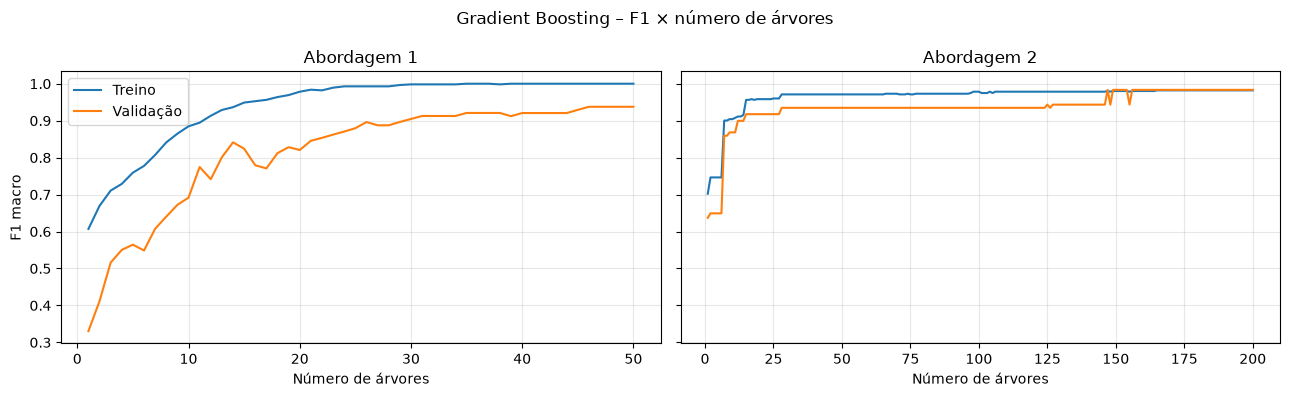

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, ab in zip(axes, ABORDAGENS):
    Xtr, ytr, Xval, yval, _, _ = dados[ab]
    m = modelos[ab]
    f1_tr = [f1_score(ytr, p, average="macro") for p in m.staged_predict(Xtr)]
    f1_va = [f1_score(yval, p, average="macro") for p in m.staged_predict(Xval)]
    eixo = range(1, len(f1_tr) + 1)
    ax.plot(eixo, f1_tr, label="Treino")
    ax.plot(eixo, f1_va, label="Validação")
    ax.set_title(f"Abordagem {ab}")
    ax.set_xlabel("Número de árvores")
    ax.grid(alpha=.3)

axes[0].set_ylabel("F1 macro")
axes[0].legend()
fig.suptitle("Gradient Boosting – F1 × número de árvores")
fig.tight_layout()
fig.savefig("boosting_overfitting.png", dpi=150)
plt.show()


### 3.3 Interpretação dos resultados de overfitting

- **Abordagem 1:** a validação melhora conforme as árvores são adicionadas, chegando a aproximadamente 0,94 de F1 macro. Há **algum overfitting**, pois o treino chega a 1,0 enquanto a validação permanece abaixo desse valor. Mesmo assim, a validação não apresenta uma queda significativa no final.

- **Abordagem 2:** **não há sinais relevantes de overfitting**. Treino e validação ficam próximos de 0,98 de F1 macro, com pequenas oscilações. As características extraídas do tabuleiro facilitam o aprendizado e permitem um desempenho elevado.

- **Comparação:** a Abordagem 2 apresenta melhor generalização, com treino e validação próximos de 0,98 de F1 macro. A Abordagem 1 utiliza menos árvores, mas mantém uma diferença maior entre treino e validação, indicando maior tendência ao overfitting.

## 4. Resultados dos experimentos

### 4.1 Comparação entre as abordagens

Desempenho dos modelos escolhidos na **validação**, com o custo de treino.

In [28]:
linhas = []
for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, _, _ = dados[ab]
    linhas.append({"abordagem": ab, "n_features": Xtr.shape[1],
                   **metricas(yval, modelos[ab].predict(Xval)),
                   "n_arvores": melhores_params[ab]["n_estimators"],
                   "profundidade_arvores": melhores_params[ab]["max_depth"],
                   "tempo_treino_ms": tempos[ab]})
comparacao_val = pd.DataFrame(linhas).set_index("abordagem")
print(comparacao_val.round(4))

melhor_abordagem = comparacao_val["f1"].idxmax()

print(f"Melhor abordagem: {melhor_abordagem}")
print(f"F1 macro: {comparacao_val.loc[melhor_abordagem, 'f1']:.4f}")

           n_features  acuracia  precision  recall      f1  n_arvores  \
abordagem                                                               
1                   9    0.9785     0.9836  0.9083  0.9376         50   
2                  15    0.9785     0.9844  0.9833  0.9833        200   

           profundidade_arvores  tempo_treino_ms  
abordagem                                         
1                             3          67.6764  
2                             1         157.0664  
Melhor abordagem: 2
F1 macro: 0.9833


### 4.2 Gráfico comparativo

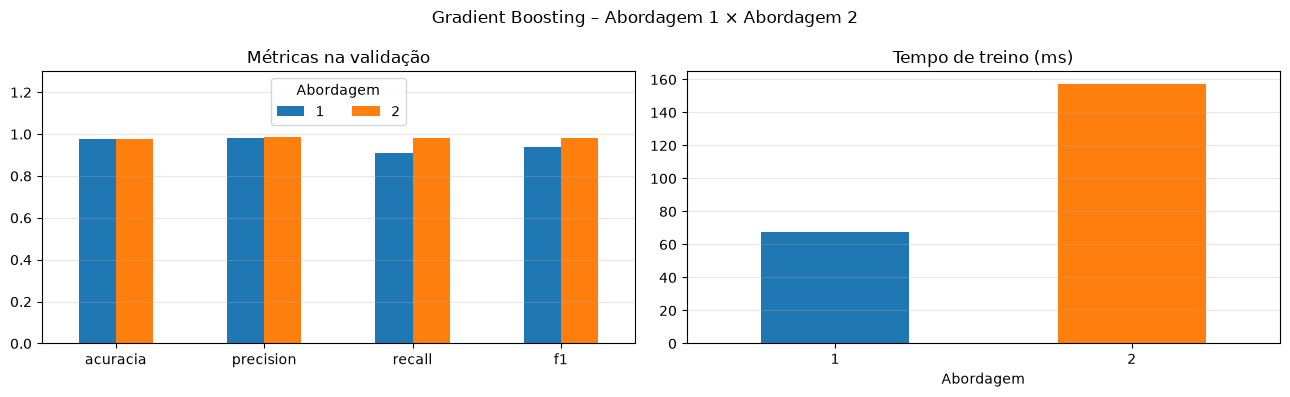

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

comparacao_val[["acuracia", "precision", "recall", "f1"]].T.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Métricas na validação")
axes[0].set_ylim(0, 1.3)
axes[0].legend(title="Abordagem", loc="upper center", ncol=2)
axes[0].grid(axis="y", alpha=.3)

comparacao_val["tempo_treino_ms"].plot.bar(ax=axes[1], rot=0, color=["tab:blue", "tab:orange"])
axes[1].set_title("Tempo de treino (ms)")
axes[1].set_xlabel("Abordagem")
axes[1].grid(axis="y", alpha=.3)

fig.suptitle("Gradient Boosting – Abordagem 1 × Abordagem 2")
fig.tight_layout()
fig.savefig("boosting_comparativo.png", dpi=150)
plt.show()


### 4.3 Avaliação no conjunto de teste

Avaliação única da melhor abordagem, selecionada pelo F1 macro na validação, em tabuleiros que não foram usados nem para treinar nem para escolher parâmetros. O modelo é salvo (`.joblib`) para uso no front end.

===== Abordagem 2 =====
              precision    recall  f1-score   support

      Empate       1.00      1.00      1.00         3
    O venceu       1.00      1.00      1.00        30
    Tem jogo       1.00      0.87      0.93        30
    X venceu       0.88      1.00      0.94        30

    accuracy                           0.96        93
   macro avg       0.97      0.97      0.97        93
weighted avg       0.96      0.96      0.96        93



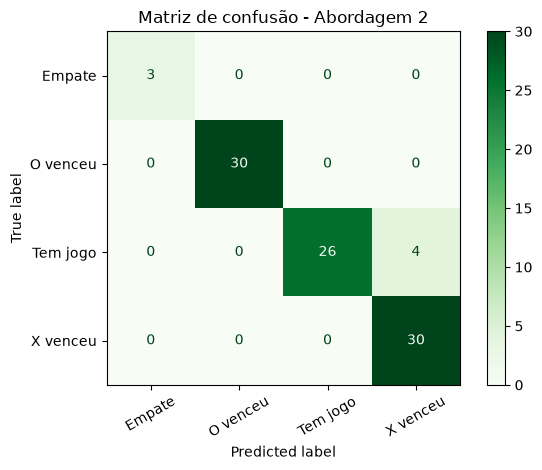

   abordagem  n_estimators  learning_rate  max_depth pesos  acuracia  \
0          2           200            0.3          1  None     0.957   

   precision  recall      f1  tempo_treino_ms  tempo_pred_ms  
0     0.9706  0.9667  0.9665         157.0664         3.9465  


In [30]:

# Avaliação final da melhor abordagem
ab = melhor_abordagem

_, _, _, _, Xte, yte = dados[ab]
m = modelos[ab]

t0 = time.perf_counter()
pred = m.predict(Xte)
tempo_pred = (time.perf_counter() - t0) * 1000

print(f"===== Abordagem {ab} =====")
print(classification_report(yte, pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    yte, pred, cmap="Greens"
)

plt.title(f"Matriz de confusão - Abordagem {ab}")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("boosting_matriz_confusao.png", dpi=150)
plt.show()

resultados_teste = pd.DataFrame([{
    "abordagem": ab,
    **melhores_params[ab],
    **metricas(yte, pred),
    "tempo_treino_ms": tempos[ab],
    "tempo_pred_ms": tempo_pred
}])

joblib.dump(m, f"boosting_modelo_ab{ab}.joblib")

resultados_teste.to_csv(
    "boosting_resultados_teste.csv",
    index=False
)

print(resultados_teste.round(4))


### 4.4 Análise dos resultados

**Em que o modelo se apoia:** importância das features em cada abordagem.

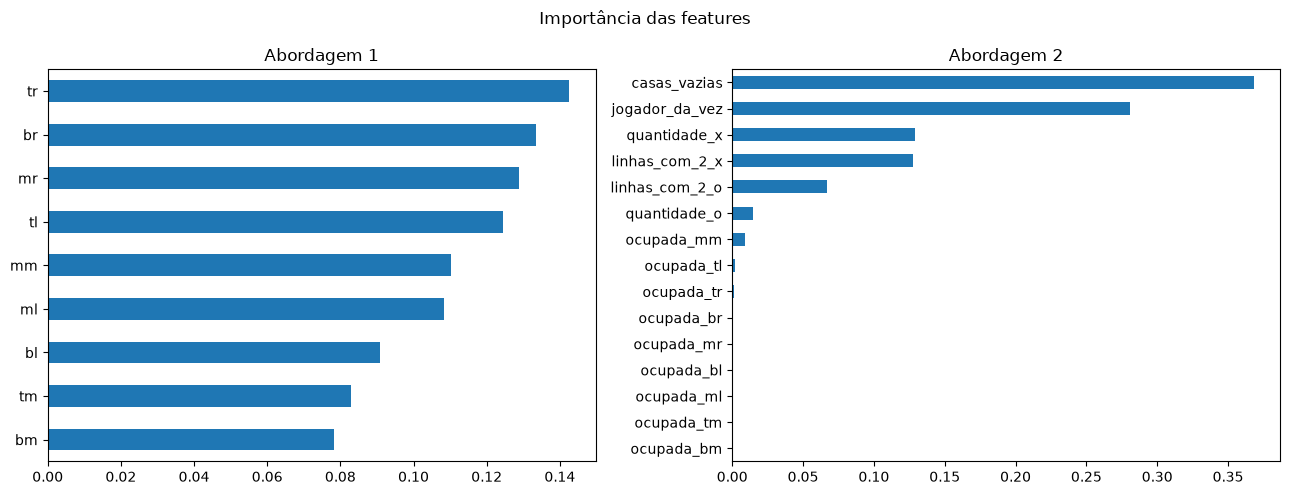

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ab in zip(axes, ABORDAGENS):
    imp = pd.Series(modelos[ab].feature_importances_, dados[ab][0].columns).sort_values()
    imp.plot.barh(ax=ax)
    ax.set_title(f"Abordagem {ab}")
fig.suptitle("Importância das features")
fig.tight_layout()
fig.savefig("boosting_importancia.png", dpi=150)
plt.show()

- **As duas abordagens têm acurácia alta** (0,9785), mas o F1 macro mostra a diferença: 0,9376 na Abordagem 1 contra 0,9833 na Abordagem 2. A diferença está principalmente no desempenho entre as classes.
- **O boosting resolve bem a Abordagem 1:** combinando 50 árvores de profundidade 3, consegue reconhecer padrões do jogo mesmo utilizando apenas as posições individuais do tabuleiro.
- **Na Abordagem 2, as árvores são mais simples:** possuem profundidade 1, mas o modelo utiliza 200 árvores. Por isso, o treinamento é mais demorado (152,09 ms contra 68,68 ms).
- **Cautela com o Empate:** o teste possui apenas 3 empates, então cada acerto ou erro pode alterar bastante o F1 dessa classe.

## 5. Conclusão

- A **Abordagem 2** é a mais adequada para o Gradient Boosting em termos de desempenho: apresentou melhor F1 macro na validação (0,9833 contra 0,9376) e alcançou aproximadamente 95,70% de acurácia no teste, sem sinais relevantes de overfitting.
- O boosting é robusto à escolha do pré-processamento: mesmo na Abordagem 1, alcança acurácia alta, porque a combinação de várias árvores compensa parte da falta de características mais informativas.
- A principal desvantagem é o **custo computacional**: a Abordagem 2 precisou de mais árvores e maior tempo de treinamento. Além disso, o modelo é menos interpretável que uma Árvore de Decisão individual.